In [1]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ecg_utils import get_dataloaders, load_label_mappings, plot_ecg
from training_functions import seed_everything

In [2]:

import numpy as np
from sklearn.metrics import roc_auc_score, f1_score

# Filepaths
cat1_path = '/Users/sahilsethi/Desktop/protoecgnet/experiments/trial_184_test_results_v0.csv'
cat3_path = '/Users/sahilsethi/Desktop/protoecgnet/experiments/trial_32_test_results_v0.csv'
cat4_path = '/Users/sahilsethi/Desktop/protoecgnet/experiments/trial_59_test_results_v0.csv'

# Load each CSV
df1 = pd.read_csv(cat1_path)
df3 = pd.read_csv(cat3_path)
df4 = pd.read_csv(cat4_path)

# Merge the three prediction tables by row index
df_all = pd.concat([df1, df3.drop(columns=["ID"]), df4.drop(columns=["ID"])], axis=1)

# Extract all label and probability columns
label_cols = [col for col in df_all.columns if col.startswith("Label_")]
prob_cols = [col for col in df_all.columns if col.startswith("Prob_")]

true_labels = df_all[label_cols].values
pred_probs = df_all[prob_cols].values

# Compute Macro AUC (averaged across all classes)
macro_auc = roc_auc_score(true_labels, pred_probs, average='macro')

# Compute F-max (maximum sample-wise F1 across thresholds)
thresholds = np.linspace(0.0, 1.0, 101)
f1_scores = []

for t in thresholds:
    preds_bin = (pred_probs >= t).astype(int)
    f1 = f1_score(true_labels, preds_bin, average='samples', zero_division=0)
    f1_scores.append(f1)

fmax = max(f1_scores)

print(f" Macro AUC: {macro_auc:.4f}")
print(f" F-max:     {fmax:.4f}")

#df_merged

 Macro AUC: 0.8918
 F-max:     0.4188


### User Inputs

In [3]:
seed = 42
# Set random seed for reproducibility
print(f"Setting random seed: {seed}")
seed_everything(seed)

dimension = '2D'  # or '2D'
label_set = '3'  # adjust as needed
custom_groups = True
sampling_rate = 100
backbone = 'resnet1d18' if dimension == '1D' else 'resnet18'

#Category 1
# pretrained_weights = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/checkpoint_dirs/cat1_static_constants_tune1_proj2/epoch=1-val_auc=0.9151.ckpt' 
# json_path = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/checkpoint_dirs/cat1_static_constants_tune1_proj2/cat1_static_constants_tune1_proj2_prototype_metadata.json'

#Category 3
#json_path = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/checkpoint_dirs/cat3_static_constants_tune1_resnet_proj1/cat3_static_constants_tune1_resnet_proj1_prototype_metadata.json' 
#pretrained_weights = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/checkpoint_dirs/cat3_static_constants_tune1_resnet_proj1/epoch=1-val_auc=0.8727.ckpt' 

# #cat1 redo check: 17 prototypes per class, batch_size 16
# json_path = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/weights/cat1_semivar2_trial128_proj1_prototype_metadata.json'
# pretrained_weights = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/weights/cat1_semivar2_trial128_proj1_projection.pth'

#cat3 redo check: 19 prototypes per class, batch_size 16
json_path = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/weights/cat3_semivar2_trial121_proj1_prototype_metadata.json'
pretrained_weights = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/weights/cat3_semivar2_trial121_proj1_projection.pth'

# #cat4 redo check: 14 prototypes per class, batch_size 16
# json_path = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/weights/cat4_semivar2_trial90_proj1_prototype_metadata.json'
# pretrained_weights = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/weights/cat4_semivar2_trial90_proj1_projection.pth'

#Category 4
#pretrained_weights = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/checkpoint_dirs/cat4_static_constants_tune1_resnet_proj/epoch=5-val_auc=0.9779.ckpt' 
#json_path = '/Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/checkpoint_dirs/cat4_static_constants_tune1_resnet_proj/cat4_static_constants_tune1_resnet_proj_prototype_metadata.json'



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
proto_time_len=3 # 3 for cat3, 32 for cat4; unused for cat1
prototypes_per_class=19 #5 for cat1, 18 for cat3, 3 for cat4
batch_size = 16 #32 for cat1, 32 for cat3, 16 for cat4


Seed set to 42


Setting random seed: 42


In [4]:
import json

# Load your projection file
with open(json_path, "r") as f:
    projections = json.load(f)

# Count how many prototypes were projected
num_projected = len(projections)
print(f"Total projected prototypes: {num_projected}")


Total projected prototypes: 988


#### Get dataloaders

In [5]:
train_loader, val_loader, test_loader, class_weights = get_dataloaders(
        batch_size=batch_size, 
        mode=dimension,
        sampling_rate=100, 
        label_set=label_set,
        work_num=4,
        return_sample_ids=True,
        custom_groups=custom_groups, 
        standardize=False,
        remove_baseline=True,
)

Loaded 52 custom group labels (Category: 3)
Final retained samples: 17418/17418
Loaded 52 custom group labels (Category: 3)
Final retained samples: 2183/2183
Loaded 52 custom group labels (Category: 3)
Final retained samples: 2198/2198


/Users/sahilsethi/Desktop/BBJ_ECG/bbj_ecg/src/ecg_utils.py:386: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(class_weights, dtype=torch.float32)



--- Data Summary ---
Training set: 17418 samples, Validation set: 2183 samples, Test set: 2198 samples
Loaded training data: X_train shape: (17418, 1000, 12), y_train shape: (17418, 52)
Loaded validation data: X_val shape: (2183, 1000, 12), y_val shape: (2183, 52)
Loaded test data: X_test shape: (2198, 1000, 12), y_test shape: (2198, 52)
Label distribution (Train): [1461.  615.   94. 2143. 1887. 1708. 1298. 1019.  894.  527.  432.  428.
  383.  341.  282.  232.  175.  171.  161.  143.  141.  135.  116.  113.
  102.   84.   79.   64.   62.   41.   35.   26.   24.   14.   13.   13.
   11. 2683.  915.  807.  701.  438.  350.  340.  318.  272.  235.  145.
   49.   28.   22.    8.]
Label distribution (Validation): [182.  75.  12. 266. 236. 210. 163. 125. 112.  66.  55.  54.  47.  43.
  36.  29.  21.  21.  20.  18.  18.  17.  15.  14.  12.  10.  10.   7.
   7.   5.   5.   4.   3.   2.   2.   2.   2. 322. 114. 101.  87.  55.
  44.  41.  40.  34.  30.  19.   7.   4.   3.   1.]
Label distribut

In [6]:
# Determine number of classes dynamically
print("Loading label mappings...")
label_mappings = load_label_mappings(
    custom_groups=custom_groups,
    prototype_category=int(label_set) if custom_groups else None
)

if custom_groups:
    num_classes = len(label_mappings["custom"])
else:
    num_classes = len(label_mappings[label_set])

Loading label mappings...
Loaded 52 custom group labels (Category: 3)


#### Load the model

In [7]:
import torch
from proto_models1D import ProtoECGNet1D
from proto_models2D import ProtoECGNet2D
from backbones import resnet1d18, ECG_CNN2D

common_kwargs = dict(
    num_classes=num_classes,
    single_class_prototype_per_class=prototypes_per_class,
    joint_prototypes_per_border=0,
    proto_dim=512,
    prototype_activation_function='log',
    latent_space_type='arc',
    add_on_layers_type='linear',
    class_specific=True,
    last_layer_connection_weight=1.0,
    m=0.05,
    dropout=0,
    custom_groups=custom_groups,
    label_set=label_set,
    pretrained_weights=pretrained_weights,
)

if dimension == '1D':
    model = ProtoECGNet1D(backbone=backbone, **common_kwargs).to(device)
elif dimension == '2D':
    model = ProtoECGNet2D(proto_time_len=proto_time_len, backbone=backbone, **common_kwargs).to(device)
else:
    raise ValueError("dimension must be '1D' or '2D'")


Initializing ProtoECGNet2D with backbone resnet18...
Full ProtoECGNet2D checkpoint detected. Skipping backbone-only loading...
Initialized prototype_vectors with shape: (988, 512, 1, 3)
Updated classifier weight matrix: Correct = 1.0, Incorrect = -0.5
Now loading full model from /Users/sahilsethi/Desktop/BBJ_ECG/miscellaneous/weights/cat3_semivar2_trial121_proj1_projection.pth
Checkpoint contains 988 prototypes. Adjusting model initialization.


In [39]:
def get_random_test_sample(test_loader): 
    """Returns a random test ECG from the DataLoader."""
    test_iter = iter(test_loader)
    batch = next(test_iter)  # Get the first batch
    X_batch, y_batch, sample_ids = batch
    idx = random.randint(0, len(X_batch) - 1)  # Select a random sample
    return X_batch[idx], y_batch[idx], sample_ids[idx]

# Function to run inference on a single sample
def run_inference(model, X_sample):
    """Runs inference on a single ECG sample and extracts prototype activations."""
    X_sample = X_sample.unsqueeze(0).to('cpu')  # Add batch dimension and move to GPU
    model.eval()
    with torch.no_grad():
        logits, _, similarity_scores = model(X_sample)  # Run inference
    probabilities = torch.sigmoid(logits).cpu().numpy().flatten()  # Convert logits to probabilities
    similarity_scores = similarity_scores.cpu().numpy().flatten()  # Prototype activations
    return probabilities, similarity_scores
sample_x, sample_y, sample_id = get_random_test_sample(test_loader)
print(sample_x)
print(sample_y)
print(sample_id)
probabilities, sim_scores = run_inference(model, sample_x)
#print(f"Logits: {logits}")
print(f"Probs: {probabilities}")
print(f"Sims: {sim_scores}")

tensor([[[-0.0357, -0.0091,  0.0385,  ..., -0.1721, -0.1603, -0.0826],
         [-0.0566, -0.0445, -0.0233,  ..., -0.1769, -0.1602, -0.1286],
         [-0.0210, -0.0363, -0.0618,  ..., -0.0038, -0.0009, -0.0460],
         ...,
         [-0.0463,  0.0535,  0.1913,  ..., -0.1935, -0.1552, -0.1551],
         [-0.0455, -0.0283,  0.0130,  ..., -0.1955, -0.1667, -0.1391],
         [-0.0366, -0.0469, -0.0471,  ..., -0.1693, -0.1404, -0.1125]]])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.])
tensor(9)
Probs: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
Sims: [ 9.393528   9.718547   9.114881   9.133366   8.469015   8.824871
  8.272126   8.870891   8.688227   9.281174   9.591633   8.587085
  9.205617

In [40]:
def compute_saliency_map(model, input_tensor, target_class_idx=None):
    """
    Computes saliency map using input gradients.
    Args:
        model: The loaded black-box ECG classification model.
        input_tensor: (C, H, W) for 2D or (C, L) for 1D. Will be unsqueezed to (1, ...).
        target_class_idx: Optional. If None, will use class with highest predicted probability.
    Returns:
        saliency: Same shape as input_tensor.
    """
    model.eval()
    input_tensor = input_tensor.unsqueeze(0).to(device).requires_grad_(True)

    output, _, _ = model(input_tensor)
    probs = torch.sigmoid(output).detach().cpu().numpy()[0]
    
    # Choose the most confident predicted class if none provided
    if target_class_idx is None:
        target_class_idx = np.argmax(probs)
    
    # Target the logit for that class
    class_logit = output[0, target_class_idx]
    class_logit.backward()

    saliency = input_tensor.grad.data.abs().squeeze().detach().cpu().numpy()
    return saliency, target_class_idx, probs[target_class_idx]


In [41]:
def highlight_saliency_on_plot(fig, raw_ecg, saliency_2d, cmap='Blues'):
    """
    Overlays saliency heatmap behind each ECG lead on the plot, including rhythm strip (lead II).
    Assumes:
    - raw_ecg: shape (1000, 12)
    - saliency_2d: shape (12, 1000)
    """
    import numpy as np
    import matplotlib.pyplot as plt

    assert raw_ecg.shape == (1000, 12), f"Expected raw_ecg shape (1000, 12), got {raw_ecg.shape}"
    assert saliency_2d.shape == (12, 1000), f"Expected saliency shape (12, 1000), got {saliency_2d.shape}"

    ax = fig.axes[0]

    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                  'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    lead_name_to_idx = {name: i for i, name in enumerate(lead_names)}

    stacked_leads = [
        ['I', 'aVR', 'V1', 'V4'],
        ['II', 'aVL', 'V2', 'V5'],
        ['III', 'aVF', 'V3', 'V6']
    ]

    mm_per_sec = 25
    row_spacing_mm = 50
    duration = 10
    t = np.linspace(0, duration, 1000)

    # Normalize saliency
    saliency_2d = np.clip(saliency_2d, 0, None)
    saliency_2d /= (saliency_2d.max() + 1e-6)

    # Plot background saliency for stacked leads
    for row_idx, lead_row in enumerate(stacked_leads):
        for col_idx, lead in enumerate(lead_row):
            lead_idx = lead_name_to_idx[lead]
            start = col_idx * 250
            end = (col_idx + 1) * 250
            t_lead = np.linspace(col_idx * 2.5, (col_idx + 1) * 2.5, 250)
            y_offset = (3 - row_idx) * row_spacing_mm + row_spacing_mm / 2

            saliency_strip = saliency_2d[lead_idx, start:end]
            ax.imshow(
                saliency_strip[np.newaxis, :],
                extent=[t_lead[0], t_lead[-1], y_offset - 25, y_offset + 25],
                cmap=cmap,
                alpha=0.5,
                aspect='auto',
                interpolation='nearest',
                zorder=1
            )

# --- Rhythm strip (Lead II) ---
    rhythm_lead = 'II'
    rhythm_idx = lead_name_to_idx[rhythm_lead]
    saliency_rhythm = saliency_2d[rhythm_idx]
    saliency_rhythm = np.clip(saliency_rhythm, 0, None)
    saliency_rhythm /= saliency_rhythm.max() + 1e-6

    # Match rhythm strip vertical offset from plot_ecg
    num_rows = len(stacked_leads) + 1  # assumes only 1 rhythm lead
    row_spacing_mm = 50
    row_baseline = num_rows * row_spacing_mm - row_spacing_mm / 2
    v_offset = row_baseline - (len(stacked_leads)) * row_spacing_mm

    ax.imshow(
        saliency_rhythm[np.newaxis, :],
        extent=[t[0], t[-1], v_offset - 25, v_offset + 25],
        cmap=cmap,
        alpha=0.5,
        aspect='auto',
        interpolation='nearest',
        zorder=1
    )



In [42]:
def get_test_sample_by_id(test_loader, target_id):
    """
    Retrieve a specific ECG sample from the test_loader by ecg_id.
    Returns: (sample_x, sample_y, sample_id) or raises ValueError if not found.
    """
    for X_batch, y_batch, id_batch in test_loader:
        for x, y, ecg_id in zip(X_batch, y_batch, id_batch):
            if int(ecg_id.item()) == target_id:
                return x, y, ecg_id.item()
    raise ValueError(f"ECG ID {target_id} not found in the test set.")


def get_random_test_sample(test_loader):
    """Returns a random test ECG from the DataLoader."""
    test_iter = iter(test_loader)
    batch = next(test_iter)  # Get the first batch
    X_batch, y_batch, sample_ids = batch
    idx = random.randint(0, len(X_batch) - 1)  # Select a random sample

    return X_batch[idx], y_batch[idx], sample_ids[idx]

# Function to run inference on a single sample
def run_inference(model, X_sample):
    """Runs inference on a single ECG sample and extracts prototype activations."""
    X_sample = X_sample.unsqueeze(0).to('cpu')  # Add batch dimension and move to GPU
    model.eval()
    with torch.no_grad():
        logits, _, similarity_scores = model(X_sample)  # Run inference
    
    probabilities = torch.sigmoid(logits).cpu().numpy().flatten()  # Convert logits to probabilities
    similarity_scores = similarity_scores.cpu().numpy().flatten()  # Prototype activations

    return probabilities, similarity_scores

Prediction: NDT
Prob: 0.0
True label: ['IRBBB']


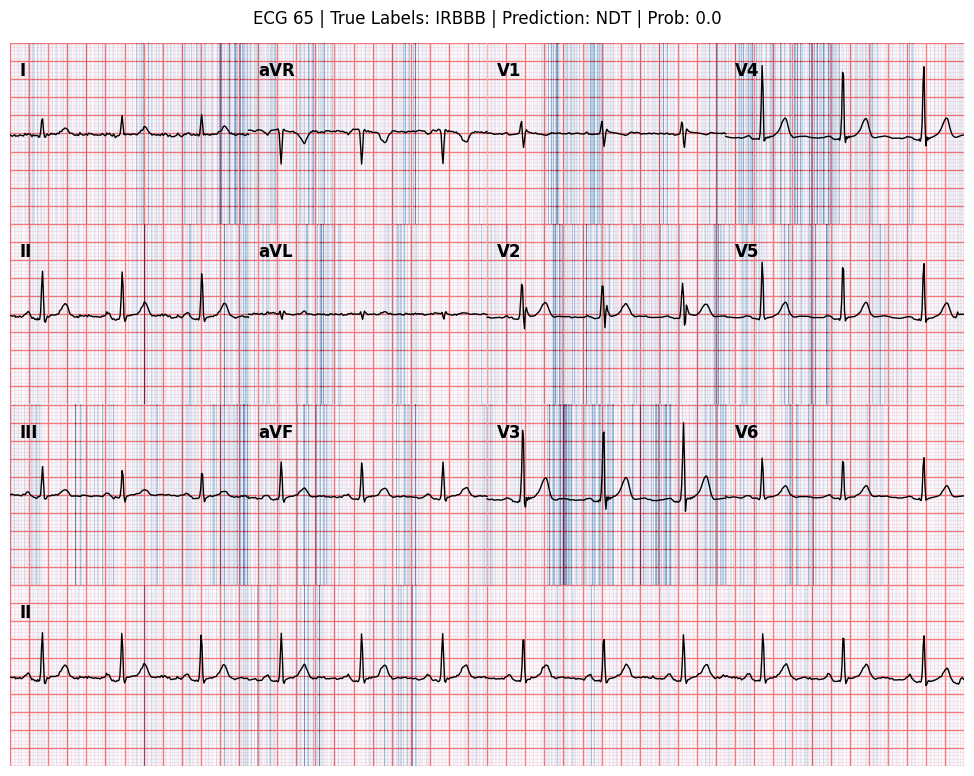

In [43]:
# --- Inference and saliency ---
sample_x, sample_y, sample_id = get_random_test_sample(test_loader)

#sample_x, sample_y, sample_id = get_test_sample_by_id(test_loader, target_id=3908)
saliency, pred_class, confidence = compute_saliency_map(model, sample_x)

# --- Convert saliency to shape (1000, 12) if needed ---
if dimension == "2D":
    if sample_x.dim() == 3:  # likely (12, 1000)
        raw_ecg = sample_x.detach().cpu().numpy().T  # (1000, 12)
        saliency = saliency  # shape (12, 1000)
    elif sample_x.dim() == 4:  # (1, 1, 12, 1000)
        raw_ecg = sample_x.squeeze().detach().cpu().numpy().T  # (1000, 12)
        saliency = saliency.squeeze()  # shape (12, 1000)
    else:
        raise ValueError(f"Unexpected sample_x shape: {sample_x.shape}")
elif dimension == "1D":
    # Handle shapes like (1, 12, 1000) or (12, 1000)
    if sample_x.dim() == 3:
        raw_ecg = sample_x.squeeze().cpu().numpy().T  # (1000, 12)
        saliency = saliency.squeeze().T  # ensure (1000, 12)
    elif sample_x.dim() == 2:
        raw_ecg = sample_x.cpu().numpy().T
        saliency = saliency.T
    else:
        raise ValueError(f"Unexpected 1D sample_x shape: {sample_x.shape}")

else:
    raise ValueError("dimension must be '1D' or '2D'")

# --- Get true label names ---
#label_mapping = {i: label_mappings[i] for i in range(len(label_mappings))}
label_mapping = {i: label_mappings['custom'][i] for i in range(len(label_mappings['custom']))}

true_label_names = [label_mapping[i] for i, v in enumerate(sample_y) if v == 1]
print(f"Prediction: {label_mapping[pred_class]}")
print(f"Prob: {confidence}")
print(f"True label: {true_label_names}")
      
# --- Plot ---
fig = plot_ecg(
    raw_ecg.squeeze(2) if raw_ecg.ndim == 3 else raw_ecg,
    ecg_id=str(int(sample_id)),  # Ensure this is string
    true_labels=true_label_names,
    prototype_labels=None,  # optionally add [predicted_label_name] here if you want
    rhythm_strip1='II'
)

# Ensure saliency shape is (12, 1000) before highlighting
if saliency.shape == (1000, 12):
    saliency_for_plot = saliency.T
elif saliency.shape == (12, 1000):
    saliency_for_plot = saliency
else:
    raise ValueError(f"Unexpected saliency shape: {saliency.shape}")

highlight_saliency_on_plot(
    fig,
    raw_ecg.squeeze(2) if raw_ecg.ndim == 3 else raw_ecg,
    saliency_for_plot
)



# Remove conflicting plt.title and use suptitle instead if needed
# Optionally override title
fig.suptitle(f"ECG {int(sample_id)} | True Labels: {', '.join(true_label_names)} | Prediction: {label_mapping[pred_class]} | Prob: {confidence}" , fontsize=12)

#plt.savefig(f'ecg_{int(sample_id)}.png', bbox_inches='tight', dpi=300)
plt.show()


In [44]:
print(saliency.shape)
print(raw_ecg.shape)

(12, 1000)
(1000, 12, 1)


In [45]:
#Inspect model weights
print("Classifier Weight Matrix (Shape: {})".format(model.classifier.weight.shape))
print(model.classifier.weight)


Classifier Weight Matrix (Shape: torch.Size([52, 988]))
Parameter containing:
tensor([[ 1.0000,  1.0000,  1.0000,  ..., -0.5000, -0.5000, -0.5000],
        [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
        [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
        ...,
        [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
        [-0.5000, -0.5000, -0.5000,  ..., -0.5000, -0.5000, -0.5000],
        [-0.5000, -0.5000, -0.5000,  ...,  1.0000,  1.0000,  1.0000]],
       requires_grad=True)


In [46]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np
import torch
from tqdm import tqdm

model.eval()
all_labels = []
all_probs = []

device = next(model.parameters()).device

with torch.no_grad():
    for X_batch, y_batch, _ in tqdm(test_loader, desc="Running test inference"):
        X_batch = X_batch.to(device)
        probs, _, _ = model(X_batch)  # Assumes model returns (probabilities, similarity_scores)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y_batch.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

# --- Macro AUC ---
macro_auc = roc_auc_score(all_labels, all_probs, average='macro')

# --- Fmax ---
thresholds = np.linspace(0.0, 1.0, 101)
f1_scores = []

for t in thresholds:
    preds = (all_probs >= t).astype(int)
    f1 = f1_score(all_labels, preds, average='samples', zero_division=0)
    f1_scores.append(f1)

fmax = max(f1_scores)

print(f"\n Macro AUC: {macro_auc:.4f}")
print(f" F-max:     {fmax:.4f}")


Running test inference: 100%|██████████| 138/138 [00:56<00:00,  2.44it/s]



 Macro AUC: 0.5203
 F-max:     0.0000


/var/folders/7j/n2z0b0r55qj8069xxy84j0lc0000gn/T/ipykernel_70567/4024612706.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Probability", y="Class", data=prob_df, ax=ax, palette="Blues_r")


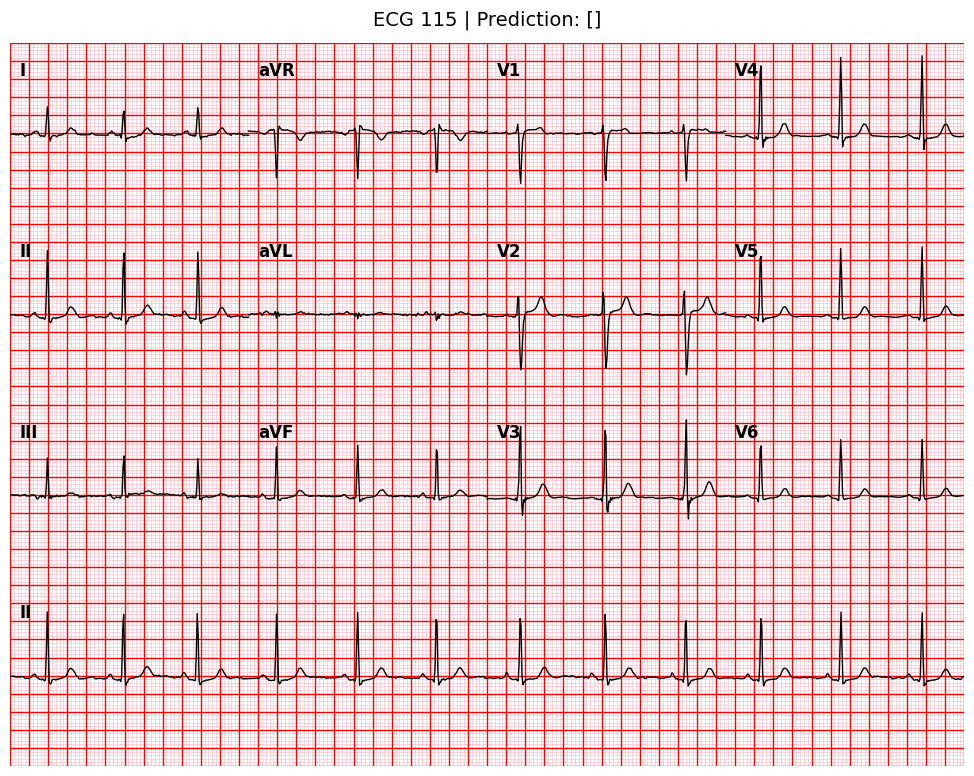

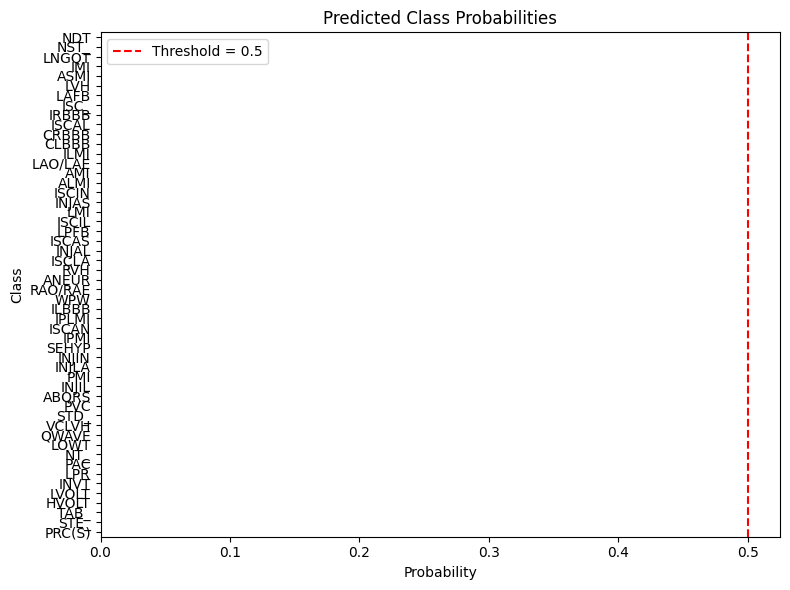


 Top Activated Prototypes:
  1. Prototype 941 (TAB_) – Score: 11.3515
  2. Prototype 923 (HVOLT) – Score: 11.2222
  3. Prototype 947 (TAB_) – Score: 11.1133
  4. Prototype 914 (HVOLT) – Score: 10.9958
  5. Prototype 920 (HVOLT) – Score: 10.9833

Mean Prototype Similarity per Predicted Class:

Predicted Classes (prob > 0.5):


In [47]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

# ---- Config ----
#json_path = "path/to/your_projection_metadata.json"  # Update as needed
top_k = 5

# ---- Load projection metadata (prototype assignments) ----
with open(json_path, "r") as f:
    prototype_metadata = json.load(f)

# ---- Build prototype → class mapping ----
prototype_class_mapping = {
    int(proto_id): meta["prototype_class"]
    for proto_id, meta in prototype_metadata.items()
}

# ---- Run inference ----
X_sample, y_sample, sample_id = get_random_test_sample(test_loader)
#X_sample, y_sample, sample_id  = get_test_sample_by_id(test_loader, target_id=3908)

true_label_indices = torch.where(y_sample == 1)[0].cpu().numpy()
true_labels = [label_mapping[i] for i in true_label_indices]

# Inference outputs
probabilities, similarity_scores = run_inference(model, X_sample)

# Get predicted labels (prob > 0.5)
predicted_label_indices = np.where(probabilities > 0.5)[0]
predicted_labels = [label_mapping[i] for i in predicted_label_indices]

# ---- Convert X_sample to (1000, 12) shape for plotting ----
x = X_sample.squeeze().cpu().numpy()

if x.shape == (12, 1000):
    raw_ecg_plot = x.T
elif x.shape == (1000, 12):
    raw_ecg_plot = x
elif x.shape == (1, 12, 1000):
    raw_ecg_plot = x.squeeze(0).T
else:
    raise ValueError(f" Unexpected shape for X_sample: {x.shape}")

# ---- Plot ECG ----
plot_ecg(
    raw_ecg_plot,
    ecg_id=f"{int(sample_id)}",
    true_labels=true_labels,
    predicted_labels=predicted_labels
)

# ---- Plot class probabilities ----
def plot_probabilities(probabilities):
    class_names = list(label_mapping.values())
    prob_df = pd.DataFrame({
        "Class": class_names,
        "Probability": probabilities
    })

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x="Probability", y="Class", data=prob_df, ax=ax, palette="Blues_r")
    ax.set_title("Predicted Class Probabilities")
    ax.axvline(0.5, color="red", linestyle="--", label="Threshold = 0.5")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_probabilities(probabilities)

# ---- Print Top Activated Prototypes ----
def get_top_prototypes(similarity_scores, top_k=5):
    top_indices = np.argsort(similarity_scores)[-top_k:][::-1]
    top_scores = similarity_scores[top_indices]
    return list(zip(top_indices, top_scores))

print("\n Top Activated Prototypes:")
top_protos = get_top_prototypes(similarity_scores, top_k=top_k)

for i, (proto_idx, score) in enumerate(top_protos):
    class_name = prototype_class_mapping.get(proto_idx, "Unknown")
    print(f"  {i+1}. Prototype {proto_idx} ({class_name}) – Score: {score:.4f}")

# ---- Compute Mean Similarity per Predicted Class ----
print("\nMean Prototype Similarity per Predicted Class:")

class_similarities = {label: [] for label in predicted_labels}

for proto_idx, score in enumerate(similarity_scores):
    class_name = prototype_class_mapping.get(proto_idx)
    if class_name in class_similarities:
        class_similarities[class_name].append(score.item())

for label in predicted_labels:
    scores = class_similarities[label]
    if scores:
        print(f"  {label}: {np.mean(scores):.4f} (from {len(scores)} prototype(s))")
    else:
        print(f"  {label}: No assigned prototypes")

# Optional: Also show predicted label + confidence max
print("\nPredicted Classes (prob > 0.5):")
for idx in predicted_label_indices:
    print(f"  {label_mapping[idx]} – Prob: {probabilities[idx]:.3f}")


In [48]:
# def highlight_test_segment_for_2dprototype(
#     model,
#     ecg_input,
#     prototype_idx,
#     proto_time_len,
#     ecg_id=None,
#     sampling_rate=100
# ):
#     """
#     For a 2D ECG input, highlights the most activated window for a specified prototype
#     and plots a 3x4 grid of the corresponding segment (like in push.py).
#     """

#     import matplotlib.pyplot as plt
#     import numpy as np

#     model.eval()
#     device = next(model.parameters()).device

#     # --- Ensure input shape ---
#     if ecg_input.dim() == 3:
#         ecg_input = ecg_input.unsqueeze(0)  # Add batch dim if missing
#     ecg_input = ecg_input.to(device)

#     with torch.no_grad():
#         _, activations = model.push_forward(ecg_input)

#     # --- Get best window ---
#     num_windows = activations.shape[-1]
#     time_scaling = 1000 / num_windows
#     window_idx = torch.argmax(activations[0, prototype_idx]).item()
#     raw_start = max(0, int(window_idx * time_scaling))
#     raw_len = int(proto_time_len * time_scaling)
#     raw_end = min(raw_start + raw_len, 1000)

#     # --- Prepare ECG for plotting ---
#     ecg_signal = ecg_input.squeeze().detach().cpu().numpy()  # shape (12, 1000)
#     if ecg_signal.shape == (1, 12, 1000):
#         ecg_signal = ecg_signal.squeeze(0)
#     elif ecg_signal.shape == (1, 1, 12, 1000):
#         ecg_signal = ecg_signal.squeeze(0).squeeze(0)

#     # Ensure (12, 1000)
#     assert ecg_signal.shape == (12, 1000), f"Expected shape (12,1000), got {ecg_signal.shape}"

#     # --- Highlight on Full ECG ---
#     from ecg_utils import plot_ecg
#     fig = plot_ecg(
#         raw_ecg=ecg_signal.T,
#         ecg_id=f"Prototype {prototype_idx} Activation | ECG ID: {ecg_id}",
#         rhythm_strip1='II'
#     )
#     ax = fig.axes[0]
#     highlight_start = raw_start / sampling_rate
#     highlight_end = raw_end / sampling_rate
#     ax.axvspan(highlight_start, highlight_end, color='blue', alpha=0.2, zorder=1)
#     plt.show()

#     # --- Segment cutout (3x4 ECG layout) ---
#     segment = ecg_signal[:, raw_start:raw_end]
#     if isinstance(segment, torch.Tensor):
#         segment = segment.cpu().numpy()

#     t_segment = np.linspace(highlight_start, highlight_end, segment.shape[1])
#     lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
#                   'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

#     fig_seg, axs = plt.subplots(3, 4, figsize=(12, 6), sharex=True)
#     axs = axs.flatten()

#     for i in range(12):
#         axs[i].plot(t_segment, segment[i], color='black', linewidth=1.0)
#         axs[i].set_title(lead_names[i], fontsize=10, fontweight='bold')
#         axs[i].set_xlim(t_segment[0], t_segment[-1])
#         axs[i].set_ylim(np.min(segment[i]) - 0.5, np.max(segment[i]) + 0.5)

#         # ECG grid
#         for x in np.arange(t_segment[0], t_segment[-1] + 0.04, 0.04):  # small boxes
#             axs[i].axvline(x, color='pink', linewidth=0.3, alpha=0.5)
#         for x in np.arange(t_segment[0], t_segment[-1], 0.2):  # large boxes
#             axs[i].axvline(x, color='red', linewidth=0.5, alpha=0.7)

#     for ax in axs:
#         ax.tick_params(left=False, labelleft=False, bottom=False)

#     fig_seg.suptitle(f"Test ECG Segment Most Similar to Prototype {prototype_idx} | ECG {ecg_id}", fontsize=14)
#     plt.tight_layout()
#     plt.show()


In [49]:
def highlight_test_segment_for_2dprototype(
    model,
    ecg_input,
    prototype_idx,
    proto_time_len,
    ecg_id=None,
    sampling_rate=100
):
    """
    Highlights the most activated segment for a 2D prototype and shows:
    (1) Full ECG with highlighted window
    (2) Zoomed segment with clinical 12-lead print-style layout
    """
    import matplotlib.pyplot as plt
    import numpy as np

    model.eval()
    device = next(model.parameters()).device

    if ecg_input.dim() == 3:
        ecg_input = ecg_input.unsqueeze(0)
    ecg_input = ecg_input.to(device)

    with torch.no_grad():
        _, activations = model.push_forward(ecg_input)

    # Get best-activated window
    num_windows = activations.shape[-1]
    time_scaling = 1000 / num_windows
    window_idx = torch.argmax(activations[0, prototype_idx]).item()
    raw_start = max(0, int(window_idx * time_scaling))
    raw_len = int(proto_time_len * time_scaling)
    raw_end = min(raw_start + raw_len, 1000)

    # Prepare raw ECG
    ecg_signal = ecg_input.squeeze().detach().cpu().numpy()
    if ecg_signal.shape == (1, 12, 1000):
        ecg_signal = ecg_signal.squeeze(0)
    elif ecg_signal.shape == (1, 1, 12, 1000):
        ecg_signal = ecg_signal.squeeze(0).squeeze(0)
    assert ecg_signal.shape == (12, 1000), f"Expected shape (12,1000), got {ecg_signal.shape}"

    # --- Full ECG with highlight ---
    from ecg_utils import plot_ecg
    fig = plot_ecg(
        raw_ecg=ecg_signal.T,
        ecg_id=f"Prototype {prototype_idx} Activation | ECG ID: {ecg_id}",
        rhythm_strip1='II'
    )
    ax = fig.axes[0]
    highlight_start = raw_start / sampling_rate
    highlight_end = raw_end / sampling_rate
    ax.axvspan(highlight_start, highlight_end, color='blue', alpha=0.2, zorder=1)
    plt.show()

    # --- Segment Cutout (print layout) ---
    segment = ecg_signal[:, raw_start:raw_end]
    if isinstance(segment, torch.Tensor):
        segment = segment.cpu().numpy()

    t_segment = np.linspace(highlight_start, highlight_end, segment.shape[1])
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                  'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    layout = [
        ['I', 'aVR', 'V1', 'V4'],
        ['II', 'aVL', 'V2', 'V5'],
        ['III', 'aVF', 'V3', 'V6']
    ]

    lead_idx_map = {name: i for i, name in enumerate(lead_names)}

    fig_seg, axs = plt.subplots(3, 4, figsize=(14, 6), sharex=True)
    for row in range(3):
        for col in range(4):
            lead = layout[row][col]
            i = lead_idx_map[lead]
            ax = axs[row, col]
            ax.plot(t_segment, segment[i], color='black', linewidth=1.0)
            ax.set_xlim(t_segment[0], t_segment[-1])
            ax.set_ylim(np.min(segment[i]) - 0.5, np.max(segment[i]) + 0.5)

            # Draw lead label to the left of the plot
            ax.text(t_segment[0] - 0.1, np.max(segment[i]), lead,
                    fontsize=10, fontweight='bold', ha='right', va='top')

            # ECG grid
            for x in np.arange(t_segment[0], t_segment[-1] + 0.04, 0.04):
                ax.axvline(x, color='pink', linewidth=0.3, alpha=0.5)
            for x in np.arange(t_segment[0], t_segment[-1], 0.2):
                ax.axvline(x, color='red', linewidth=0.5, alpha=0.7)

            ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)


    fig_seg.suptitle(
        f"Test ECG Segment Most Similar to Prototype {prototype_idx} | ECG {ecg_id}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()


In [50]:
def highlight_test_segment_for_2dprototype(
    model,
    ecg_input,
    prototype_idx,
    proto_time_len,
    ecg_id=None,
    sampling_rate=100
):
    import matplotlib.pyplot as plt
    import numpy as np

    model.eval()
    device = next(model.parameters()).device

    # Ensure correct shape: (1, 1, 12, 1000)
    if ecg_input.dim() == 3:  # (12, 1000)
        ecg_input = ecg_input.unsqueeze(0).unsqueeze(0)
    elif ecg_input.dim() == 4 and ecg_input.shape[1] == 12:  # (1, 12, 1000)
        ecg_input = ecg_input.unsqueeze(1)
    ecg_input = ecg_input.to(device)

    with torch.no_grad():
        _, activations = model.push_forward(ecg_input)

    # Identify best time window for prototype
    num_windows = activations.shape[-1]
    time_scaling = 1000 / num_windows
    window_idx = torch.argmax(activations[0, prototype_idx]).item()
    raw_start = max(0, int(window_idx * time_scaling))
    raw_len = int(proto_time_len * time_scaling)
    raw_end = min(raw_start + raw_len, 1000)

    # Extract ECG and segment
    ecg_signal = ecg_input.squeeze().cpu().numpy()  # (12, 1000)
    assert ecg_signal.shape == (12, 1000), f"Expected (12,1000), got {ecg_signal.shape}"

    segment = ecg_signal[:, raw_start:raw_end]
    t_segment = np.linspace(raw_start / sampling_rate, raw_end / sampling_rate, segment.shape[1])

    # Lead layout per row
    lead_order = [
        ['I', 'aVR', 'V1', 'V4'],
        ['II', 'aVL', 'V2', 'V5'],
        ['III', 'aVF', 'V3', 'V6']
    ]
    lead_name_to_index = {
        'I': 0, 'II': 1, 'III': 2,
        'aVR': 3, 'aVL': 4, 'aVF': 5,
        'V1': 6, 'V2': 7, 'V3': 8,
        'V4': 9, 'V5': 10, 'V6': 11
    }

    fig, axs = plt.subplots(3, 4, figsize=(14, 6), sharex=True)
    for row in range(3):
        for col in range(4):
            lead = lead_order[row][col]
            idx = lead_name_to_index[lead]
            ax = axs[row][col]
            signal = segment[idx]

            # Plot waveform
            ax.plot(t_segment, signal, color='black', linewidth=1.0)
            ax.set_xlim(t_segment[0], t_segment[-1])
            ax.set_ylim(signal.min() - 0.5, signal.max() + 0.5)

            # Add vertical grid
            for x in np.arange(t_segment[0], t_segment[-1] + 0.04, 0.04):
                ax.axvline(x, color='pink', linewidth=0.3, alpha=0.5)
            for x in np.arange(t_segment[0], t_segment[-1], 0.2):
                ax.axvline(x, color='red', linewidth=0.6, alpha=0.8)

            # Add horizontal grid
            for y in np.arange(signal.min() - 0.5, signal.max() + 0.5, 0.1):
                is_major = np.round(y * 10) % 5 == 0
                ax.axhline(y, color='pink' if not is_major else 'red',
                           linewidth=0.3 if not is_major else 0.6, alpha=0.5)

            # Lead label on leftmost axes only
            if col == 0:
                ax.set_ylabel(lead, rotation=0, labelpad=25, fontsize=10, fontweight='bold')
            else:
                ax.set_ylabel("")

            # Tick styling
            ax.tick_params(axis='y', left=False, labelleft=False)
            ax.tick_params(axis='x', labelsize=8)

    axs[2][3].set_xlabel("Time (s)", fontsize=10)
    fig.suptitle(f"Test ECG Segment Most Similar to Prototype {prototype_idx} | ECG {ecg_id}", fontsize=14)
    plt.tight_layout()
    plt.show()


In [51]:
# After running inference on a selected ECG
if dimension == "2D":
    _, similarity_scores = run_inference(model, X_sample)
    similarity_map = similarity_scores.reshape(model.num_prototypes, -1)  # or just use activations directly
    highlight_test_segment_for_2dprototype(
        model=model,
        ecg_input=X_sample,  # Should be shape (1, 1, 12, 1000)
        prototype_idx=80,
        proto_time_len=model.proto_time_len,
        ecg_id=sample_id
    )


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [1, 1, 1, 12, 1000]

In [ ]:
def highlight_rhythm_and_zoom_1d(ecg, ecg_id=None, lead="II"):
    """
    Highlights the full rhythm strip and shows a zoomed-in 10s view
    with ECG paper-style grid formatting.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Ensure (1000, 12) shape for plotting
    if ecg.shape == (12, 1000):
        raw_ecg_for_plot = ecg.T
    elif ecg.shape == (1000, 12):
        raw_ecg_for_plot = ecg
    elif ecg.shape == (1, 12, 1000):
        raw_ecg_for_plot = ecg.squeeze(0).T
    elif ecg.shape == (1, 1, 12, 1000):
        ecg = ecg.squeeze(0)
        raw_ecg_for_plot = ecg.squeeze(0).T
    else:
        raise ValueError(f"ECG shape must be (12,1000) or (1000,12). Got {ecg.shape}")

    # ---- Full ECG with rhythm strip shown ----
    fig = plot_ecg(
        raw_ecg=raw_ecg_for_plot,
        sampling_rate=100,
        ecg_id=ecg_id,
        rhythm_strip1=lead,
    )

    # ---- Zoomed-in Rhythm Strip (Styled) ----
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    lead_idx = lead_names.index(lead)
    signal = raw_ecg_for_plot[:, lead_idx]
    t = np.linspace(0, 10, 1000)

    fig_rhythm, ax = plt.subplots(figsize=(10, 2))

    # Vertical grid lines
    for x in np.arange(0, 10.04, 0.04):
        ax.axvline(x, color='pink', linewidth=0.5, zorder=0)
    for x in np.arange(0, 10.2, 0.2):
        ax.axvline(x, color='red', linewidth=1.0, zorder=0)

    # Horizontal grid lines
    y_min, y_max = signal.min(), signal.max()
    step = 0.1  # ~1 mm at 10 mm/mV
    for y in np.arange(y_min - 0.2, y_max + 0.2, step):
        is_large = np.round(y * 10) % 5 == 0
        ax.axhline(y, color='pink' if not is_large else 'red',
                   linewidth=0.5 if not is_large else 1.0, zorder=0)

    # Plot the ECG signal
    ax.plot(t, signal, color='black', linewidth=1.0)
    ax.set_title(f"ECG {ecg_id} | Lead {lead} Rhythm Strip", fontsize=12)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, 10)

    plt.tight_layout()
    plt.show()


In [38]:




if dimension == "1D":
    highlight_rhythm_and_zoom_1d(X_sample, ecg_id=sample_id, lead="II")